In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
traders = pd.read_csv("historical_data.csv")
fg = pd.read_csv("fear_greed_index.csv")

In [51]:
traders.columns = traders.columns.str.strip().str.lower()
fg.columns = fg.columns.str.strip().str.lower()

In [52]:
traders['timestamp ist'] = pd.to_datetime(traders['timestamp ist'], errors='coerce')
traders['date'] = traders['timestamp ist'].dt.date

fg['date'] = pd.to_datetime(fg['date'], errors='coerce').dt.date

In [53]:
traders = traders.dropna(subset=['closed pnl'])
traders = traders[traders['closed pnl'].between(-100000, 100000)]

In [54]:
df = pd.merge(traders, fg, on='date', how='inner')

In [55]:
print(df.head())
print(df.columns)

                                      account  coin  execution price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size tokens  size usd side       timestamp ist  start position direction  \
0       986.87   7872.16  BUY 2024-02-12 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-02-12 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-02-12 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-02-12 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-02-12 22:50:00     1289.488521       Buy   

   closed pnl                                   transaction hash     order id  \
0         0

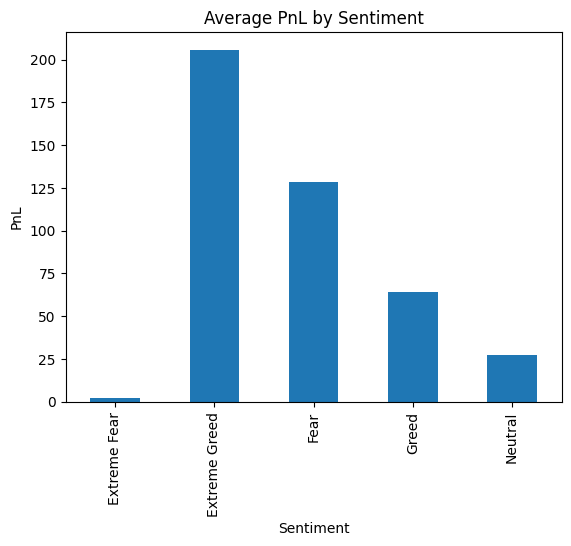

In [56]:
df.groupby('classification')['closed pnl'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("PnL")
plt.show()

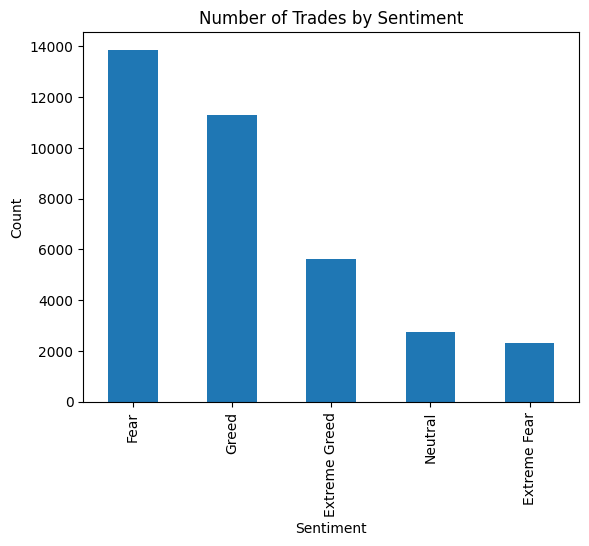

In [57]:
df['classification'].value_counts().plot(kind='bar')
plt.title("Number of Trades by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

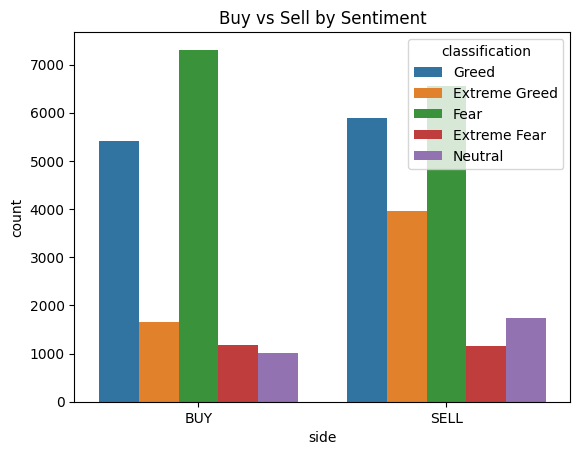

In [58]:
sns.countplot(data=df, x='side', hue='classification')
plt.title("Buy vs Sell by Sentiment")
plt.show()

In [61]:
print(df.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification'],
      dtype='object')


In [64]:
# Find correct leverage column automatically
lev_cols = [col for col in df.columns if 'leverage' in col]

print("Leverage columns found:", lev_cols)

# Check if any leverage column exists
if len(lev_cols) == 0:
    print("No leverage column found ❌")
else:
    lev_col = lev_cols[0]

    # Convert to numeric safely
    df[lev_col] = pd.to_numeric(df[lev_col], errors='coerce')

    # Drop missing values
    temp_df = df.dropna(subset=[lev_col])

    # Plot
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.boxplot(data=temp_df, x='classification', y=lev_col)
    plt.title("Leverage vs Sentiment")
    plt.show()

Leverage columns found: []
No leverage column found ❌
